In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

/home/tristan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [58]:
dt = pd.read_csv("dataset.csv")
dt

,Unnamed: 0,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
0,1,NaN,1.0,NaN,NaN,2.0,3.0,NaN,3.0,1,NaN
1,2,51.240996,2.0,16.874618,1.0,1.0,1.0,2.0,1.0,1,1.0
2,3,NaN,2.0,NaN,NaN,1.0,NaN,NaN,2.0,1,NaN
3,4,NaN,1.0,25.608588,NaN,NaN,2.0,NaN,NaN,NaN,1.0
4,5,55.254881,2.0,43.438748,2.0,1.0,3.0,1.0,3.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...
297,2651,52.048990,2.0,33.089490,11.0,NaN,3.0,1.0,2.0,2,1.0
298,308,75.745550,2.0,15.239369,9.0,NaN,1.0,1.0,2.0,2,2.0
299,347,54.688155,2.0,23.642077,2.0,NaN,1.0,1.0,2.0,1,2.0
300,378,57.920124,2.0,22.087332,2.0,NaN,1.0,1.0,3.0,1,2.0


In [4]:
dt = dt.drop("Unnamed: 0", axis="columns", inplace=False)

In [5]:
dt.dtypes

Age                  float64
Menopause            float64
Taille_tumeur        float64
Ganglions_touches    float64
Metastases           float64
Grade                float64
Lateralite           float64
Quadrant             float64
Irradiation           object
Recidive             float64
dtype: object

<h4>To see if there's no relevant Age data</h4>

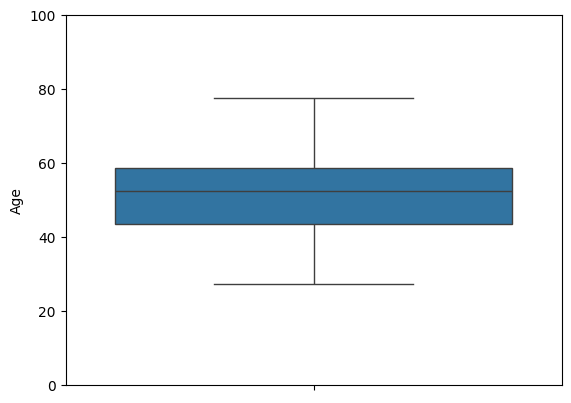

In [19]:
sns.boxplot(data = dt["Age"])
plt.ylim(0, 100)
plt.show()

In [17]:
dt["Age"].describe()

count    192.000000
mean      53.059182
std       26.269277
min       27.269382
25%       43.416635
50%       52.367426
75%       58.709683
max      378.787350
Name: Age, dtype: float64

<h4>To see if there's more than 3 values for the menopause and 4 for the grade</h4>

In [11]:
dt["Menopause"].value_counts()

Menopause
1.0    135
2.0    127
Name: count, dtype: int64

In [ ]:
#We good fot the menopause variable

In [21]:
dt.Grade.value_counts()

Grade
2.0     97
3.0     72
1.0     54
34.0     1
Name: count, dtype: int64

In [ ]:
#We only have 1 record with the observation 34. We can suppose that the doctor type 34 by mistake. The one wanted was probably 3

<h5>No the correlation between the age and the menopause</h5>

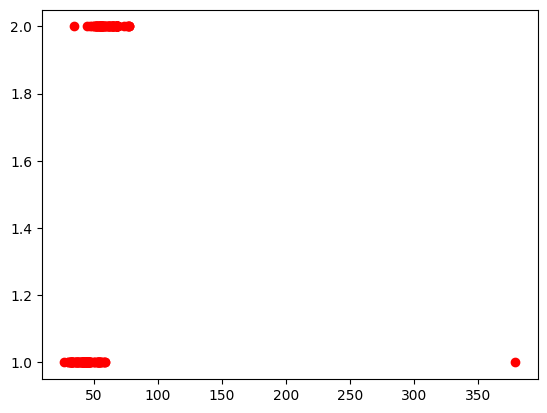

In [9]:
plt.scatter(dt["Age"], dt["Menopause"], color="red")
plt.show()

In [20]:
#The values of age are very close so the scatter plot doesn't give much information. We can't see clearly if there's a pattern

<h4>Tumor size density</h4>

In [59]:
rounded = dt
#rounded["Taille_tumeur"] = round(rounded["Taille_tumeur"], 0)

<Axes: ylabel='Density'>

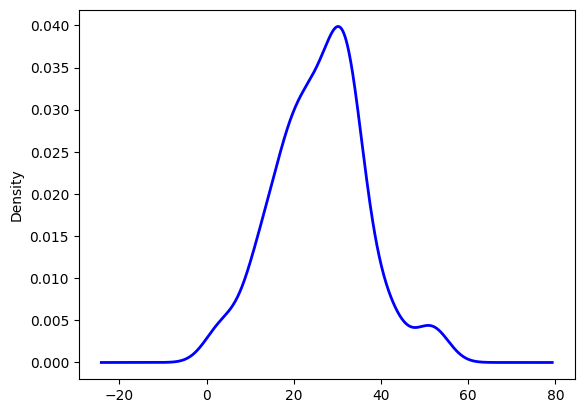

In [60]:
rounded["Taille_tumeur"].plot.density(bw_method='scott', color='blue', linestyle='-', linewidth=2)


In [61]:
rounded["Taille_tumeur"].describe()

count    196.000000
mean      26.127106
std       10.389460
min        1.714647
25%       18.812693
50%       26.549199
75%       32.257666
max       53.422745
Name: Taille_tumeur, dtype: float64

In [ ]:
#Un graphique Q-Q (Quantile-Quantile) est utilisé pour vérifier si un ensemble de données suit une distribution théorique particulière.
#QQPlot on tumor size + Shapiro test to see if it rejects null hypotesis ( pvalue > 0.5 )

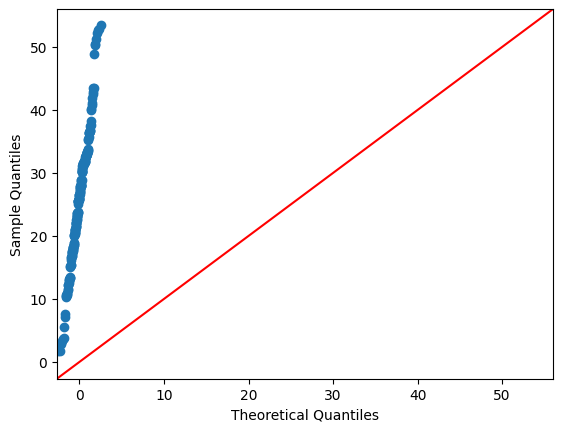

In [67]:
import statsmodels.api as sm
import pylab as py

sm.qqplot(rounded["Taille_tumeur"], line = '45')
py.show()

In [63]:
from scipy.stats import shapiro

shapiroo = shapiro(rounded["Taille_tumeur"])
shapiroo

ShapiroResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [65]:
#It doesn't work with Null Values
rounded = rounded.dropna(subset=["Taille_tumeur"])
rounded

,Unnamed: 0,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
1,2,51.240996,2.0,16.874618,1.0,1.0,1.0,2.0,1.0,1,1.0
3,4,NaN,1.0,25.608588,NaN,NaN,2.0,NaN,NaN,NaN,1.0
4,5,55.254881,2.0,43.438748,2.0,1.0,3.0,1.0,3.0,1,1.0
5,6,46.298965,1.0,10.601184,2.0,1.0,2.0,1.0,3.0,1,1.0
9,10,56.972747,2.0,30.606762,0.0,NaN,NaN,2.0,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
297,2651,52.048990,2.0,33.089490,11.0,NaN,3.0,1.0,2.0,2,1.0
298,308,75.745550,2.0,15.239369,9.0,NaN,1.0,1.0,2.0,2,2.0
299,347,54.688155,2.0,23.642077,2.0,NaN,1.0,1.0,2.0,1,2.0
300,378,57.920124,2.0,22.087332,2.0,NaN,1.0,1.0,3.0,1,2.0


In [66]:
shapiroo = shapiro(rounded["Taille_tumeur"])
shapiroo

ShapiroResult(statistic=np.float64(0.9834111157624116), pvalue=np.float64(0.0205546977172848))

In [68]:
#P_value < 0.05 so we reject null hypothesis. Like the QQPlot shows us, the tumor size is not following the normal law